# Reddit Data Preprocessing

Preprocesses Reddit Ethereum posts and comments into daily aggregated features.
Includes visualization to determine optimal date filtering.

**Features extracted:**
- Daily activity counts (posts, comments)
- Sentiment statistics (mean, std)
- Fraud keyword mentions
- Engagement scores

In [1]:
import pandas as pd
import re
import os

In [2]:
posts = pd.read_csv('../data/raw/reddit/the-reddit-ethereum-dataset-posts.csv')
comments = pd.read_csv('../data/raw/reddit/the-reddit-ethereum-dataset-comments.csv')

In [3]:
print(f"posts: {posts.shape}")
print(f"comments: {comments.shape}")

posts: (479260, 12)
comments: (1132331, 10)


### Explore Data

In [4]:
print("posts overview")
print(f"shape: {posts.shape}")
print(f"\ncolumns: {posts.columns.tolist()}")
print(f"\ndata types:\n{posts.dtypes}")
posts.head(2)

posts overview
shape: (479260, 12)

columns: ['type', 'id', 'subreddit.id', 'subreddit.name', 'subreddit.nsfw', 'created_utc', 'permalink', 'domain', 'url', 'selftext', 'title', 'score']

data types:
type              object
id                object
subreddit.id      object
subreddit.name    object
subreddit.nsfw      bool
created_utc        int64
permalink         object
domain            object
url               object
selftext          object
title             object
score              int64
dtype: object


,type,id,subreddit.id,subreddit.name,subreddit.nsfw,created_utc,permalink,domain,url,selftext,title,score
0,post,qkrfg9,2qiux,riddles,False,1635811168,https://old.reddit.com/r/riddles/comments/qkrf...,self.riddles,NaN,[removed],Ethereum Extasy SOMEONE PLEASE SOLVE THIS FOR ...,0
1,post,qkr8mn,2ruj5,xrp,False,1635810613,https://old.reddit.com/r/XRP/comments/qkr8mn/a...,self.xrp,NaN,[removed],Anyone have any insight on the Davis Schwartz ...,1


In [5]:
print("comments overview")
print(f"shape: {comments.shape}")
print(f"\ncolumns: {comments.columns.tolist()}")
print(f"\nsentiment stats:\n{comments['sentiment'].describe()}")
print(f"\nsentiment null count: {comments['sentiment'].isna().sum()} ({comments['sentiment'].isna().mean()*100:.2f}%)")

comments overview
shape: (1132331, 10)

columns: ['type', 'id', 'subreddit.id', 'subreddit.name', 'subreddit.nsfw', 'created_utc', 'permalink', 'body', 'sentiment', 'score']

sentiment stats:
count    1.101534e+06
mean     3.231925e-01
std      5.323997e-01
min     -9.998000e-01
25%      0.000000e+00
50%      4.200000e-01
75%      8.009000e-01
max      1.000000e+00
Name: sentiment, dtype: float64

sentiment null count: 30797 (2.72%)


### Convert Timestamps to Daily Date

In [6]:
posts['day'] = pd.to_datetime(posts['created_utc'], unit='s', utc=True).dt.date
comments['day'] = pd.to_datetime(comments['created_utc'], unit='s', utc=True).dt.date

posts['day'] = pd.to_datetime(posts['day'])
comments['day'] = pd.to_datetime(comments['day'])

print(f"Posts date range: {posts['day'].min()} to {posts['day'].max()}")
print(f"Comments date range: {comments['day'].min()} to {comments['day'].max()}")

Posts date range: 2011-07-03 00:00:00 to 2021-11-01 00:00:00
Comments date range: 2011-05-25 00:00:00 to 2021-11-01 00:00:00


### Extract Fraud Keyword Mentions

In [7]:
fraud_keywords = [
    # General fraud
    'scam', 'scammer', 'fraud', 'fraudulent', 'fake',
    'malicious', 'suspicious', 'warning',

    # Technical exploits
    'hack', 'hacked', 'hacker', 'exploit', 'exploited',
    'attack', 'breach', 'compromised', 'vulnerability',
    'backdoor',

    # Crypto-specific scams
    'rug pull', 'rugpull', 'rug-pull',
    'honeypot', 'exit scam',
    'phishing', 'phish',
    'ponzi', 'pyramid',

    # Theft indicators
    'stolen', 'theft', 'steal', 'drain', 'drained', 'drainer'
]

fraud_pattern = re.compile(r'\b(?:' + '|'.join(map(re.escape, fraud_keywords)) + r')\b', re.IGNORECASE)

# combine text fields for posts
posts['text'] = (posts['title'].fillna('') + ' ' + posts['selftext'].fillna('')).str.lower()
comments['text'] = comments['body'].fillna('').astype(str).str.lower()

# flag fraud mentions
posts['has_fraud_mention'] = posts['text'].str.contains(fraud_pattern, na=False).astype(int)
comments['has_fraud_mention'] = comments['text'].str.contains(fraud_pattern, na=False).astype(int)

print(f"Posts with fraud keywords: {posts['has_fraud_mention'].sum()} ({posts['has_fraud_mention'].mean()*100:.2f}%)")
print(f"Comments with fraud keywords: {comments['has_fraud_mention'].sum()} ({comments['has_fraud_mention'].mean()*100:.2f}%)")

Posts with fraud keywords: 11532 (2.41%)
Comments with fraud keywords: 64356 (5.68%)


### Aggregate to Daily Level

In [8]:
# posts daily aggregation
posts_daily = posts.groupby('day').agg(
    reddit_post_count=('id', 'count'),
    reddit_post_avg_score=('score', 'mean'),
    reddit_post_fraud_count=('has_fraud_mention', 'sum')
).reset_index()

# comments daily aggregation
comments_daily = comments.groupby('day').agg(
    reddit_comment_count=('id', 'count'),
    reddit_comment_avg_score=('score', 'mean'),
    reddit_comment_fraud_count=('has_fraud_mention', 'sum'),
    reddit_avg_sentiment=('sentiment', 'mean'),
).reset_index()

print(f"posts daily: {posts_daily.shape}")
print(f"comments daily: {comments_daily.shape}")

posts daily: (2807, 4)
comments daily: (2883, 5)


### Merge Posts and Comments Daily Features

In [9]:
# merge posts and comments
reddit_daily = pd.merge(posts_daily, comments_daily, on='day', how='outer')
reddit_daily = reddit_daily.sort_values('day').reset_index(drop=True)

# fill missing counts with 0
count_cols = ['reddit_post_count', 'reddit_comment_count', 'reddit_post_fraud_count', 'reddit_comment_fraud_count']
reddit_daily[count_cols] = reddit_daily[count_cols].fillna(0).astype(int)

### Feature Engineering

In [10]:
# create combined features
reddit_daily['reddit_total_activity'] = reddit_daily['reddit_post_count'] + reddit_daily['reddit_comment_count']

reddit_daily['reddit_total_fraud_mentions'] = reddit_daily['reddit_post_fraud_count'] + reddit_daily['reddit_comment_fraud_count']

reddit_daily['reddit_fraud_mention_ratio'] = (reddit_daily['reddit_total_fraud_mentions'] / reddit_daily['reddit_total_activity']).fillna(0)


## Handle Missing Values


In [11]:
print("missing values before fill:")
print(reddit_daily.isnull().sum())

reddit_daily = reddit_daily.fillna(0)

print("\nmissing values after fill:")
print(reddit_daily.isnull().sum().sum())

missing values before fill:
day                             0
reddit_post_count               0
reddit_post_avg_score          79
reddit_post_fraud_count         0
reddit_comment_count            0
reddit_comment_avg_score        3
reddit_comment_fraud_count      0
reddit_avg_sentiment            5
reddit_total_activity           0
reddit_total_fraud_mentions     0
reddit_fraud_mention_ratio      0
dtype: int64

missing values after fill:
0


In [12]:
print("reddit daily summary")
print(f"merged daily shape: {reddit_daily.shape}")
print(f"\ndate range: {reddit_daily['day'].min()} to {reddit_daily['day'].max()}")
print(f"\nfinal columns: {reddit_daily.columns.tolist()}")

reddit daily summary
merged daily shape: (2886, 11)

date range: 2011-05-25 00:00:00 to 2021-11-01 00:00:00

final columns: ['day', 'reddit_post_count', 'reddit_post_avg_score', 'reddit_post_fraud_count', 'reddit_comment_count', 'reddit_comment_avg_score', 'reddit_comment_fraud_count', 'reddit_avg_sentiment', 'reddit_total_activity', 'reddit_total_fraud_mentions', 'reddit_fraud_mention_ratio']


### **********Activity Statistics by Year**********

In [13]:
reddit_daily['year'] = reddit_daily['day'].dt.year
yearly_stats = reddit_daily.groupby('year').agg({
    'reddit_total_activity': 'sum',
    'reddit_post_count': 'sum',
    'reddit_comment_count': 'sum',
    'reddit_total_fraud_mentions': 'sum'
}).reset_index()

yearly_stats.columns = ['Year', 'Total Activity', 'Posts', 'Comments', 'Fraud Mentions']
yearly_stats

,Year,Total Activity,Posts,Comments,Fraud Mentions
0,2011,6,1,5,1
1,2012,5,1,4,0
2,2013,26,2,24,1
3,2014,9603,1373,8230,570
4,2015,17672,2854,14818,838
5,2016,98393,19534,78859,10173
6,2017,276751,51468,225283,15307
7,2018,295003,101225,193778,14069
8,2019,164520,73251,91269,7706
9,2020,159838,70414,89424,6614


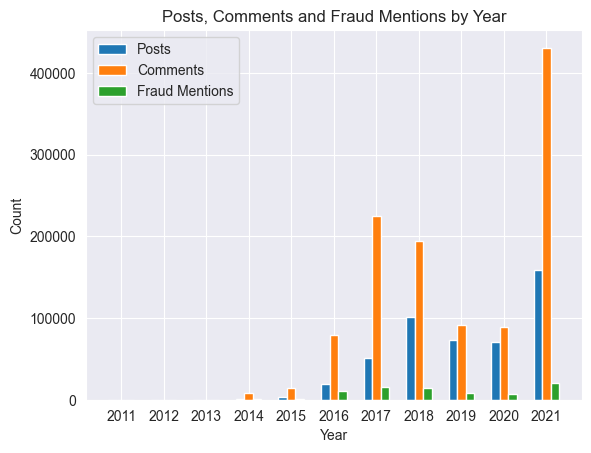

In [14]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(yearly_stats['Year']))
width = 0.2

plt.figure()

plt.bar(x - width, yearly_stats['Posts'], width)
plt.bar(x, yearly_stats['Comments'], width)
plt.bar(x + width, yearly_stats['Fraud Mentions'], width)

plt.xticks(x, yearly_stats['Year'])
plt.xlabel('Year')
plt.ylabel('Count')
plt.title('Posts, Comments and Fraud Mentions by Year')
plt.legend(['Posts', 'Comments', 'Fraud Mentions'])

plt.show()

In [15]:
selected_features = [
    'day',
    'reddit_fraud_mention_ratio',
    'reddit_total_fraud_mentions',
    'reddit_avg_sentiment',
    'reddit_total_activity',
]

reddit_daily = reddit_daily[selected_features].copy()

In [16]:
output_dir = '../data/processed/reddit'
os.makedirs(output_dir, exist_ok=True)

output_path = os.path.join(output_dir, 'reddit_daily_cleaned.parquet')
reddit_daily.to_parquet(output_path, index=False)
print("Saved")

Saved
